<a href="https://colab.research.google.com/github/DoritoNiall/Ireland-Property-Analysis/blob/main/Irish_Property_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 2: Exploratory Data Analysis & Hypothesis Testing

This notebook performs the comparative analysis between residential property values (PPR) and Short-Term Rental (STR) yields.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib.ticker as mticker
from pathlib import Path

# Set visualization style
sns.set_style("whitegrid")
pd.options.display.max_columns = None

Data_Path = "/content/drive/MyDrive/Colab Notebooks/"

# Load the cleaned datasets produced in Notebook 01
ppr = pd.read_csv(Data_Path + "PPR_2025_Cleaned.csv")
airbnb = pd.read_csv(Data_Path + "Airbnb_transformed_dataset final.csv")

print(f"Loaded {len(ppr)} PPR records and {len(airbnb)} AirBnb records.")

Loaded 61715 PPR records and 32665 AirBnb records.


2.1 Data Integration

We filter the PPR data for 'Second-Hand Dwelling house /Apartment' to represent the investable residential market. We then aggregate both datasets by County to calculate the Gross STR Yield.

In [ ]:
# 1. Define the mapping provided in your county_merge_analysis.py
LOCAL_AUTHORITY_TO_COUNTY = {
    "Mayo County Council": "Mayo",
    "Clare County Council": "Clare",
    "Galway County Council": "Galway",
    "Kilkenny County Council": "Kilkenny",
    "Dun Laoghaire-Rathdown County Council": "Dublin",
    "Sligo County Council": "Sligo",
    "Cavan County Council": "Cavan",
    "Cork County Council": "Cork",
    "Roscommon County Council": "Roscommon",
    "Wicklow County Council": "Wicklow",
    "Kerry County Council": "Kerry",
    "Dublin City Council": "Dublin",
    "Donegal County Council": "Donegal",
    "Limerick City And County Council": "Limerick",
    "Carlow County Council": "Carlow",
    "South Dublin County Council": "Dublin",
    "Kildare County Council": "Kildare",
    "Tipperary County Council": "Tipperary",
    "Galway City Council": "Galway",
    "Meath County Council": "Meath",
    "Longford County Council": "Longford",
    "Westmeath County Council": "Westmeath",
    "Offaly County Council": "Offaly",
    "Wexford County Council": "Wexford",
    "Monaghan County Council": "Monaghan",
    "Waterford City And County Council": "Waterford",
    "Fingal County Council": "Dublin",
    "Cork City Council": "Cork",
    "Leitrim County Council": "Leitrim",
    "Louth County Council": "Louth",
    "Laois County Council": "Laois",
}

# 2. Standardize PPR Counties (Ensure they are clean Title Case)
ppr['County'] = ppr['County'].astype(str).str.strip().str.title()

# 3. Align AirBnb Counties using the mapping
def align_county(name):
    name = str(name).strip().title()
    # Return the mapped county name if it exists in our dictionary
    return LOCAL_AUTHORITY_TO_COUNTY.get(name, name)

airbnb['County'] = airbnb['County'].apply(align_county)

# 4. Now perform your filtering and aggregation
ppr_res = ppr[ppr["Description of Property"] == "Second-Hand Dwelling house /Apartment"].copy()

ppr_stats = ppr_res.groupby("County")["Final_Price"].agg(["median", "mean", "count"]).reset_index()
ppr_stats.columns = ["County", "median_Final_Price", "mean_Final_Price", "sales_count"]

airbnb_stats = airbnb.groupby("County").agg(
    mean_estimated_revenue_l365d=("estimated_revenue_l365d", "mean"),
    airbnb_listing_count=("id", "count")
).reset_index()

# 5. Re-run the merge
county_stats = pd.merge(ppr_stats, airbnb_stats, on="County", how="inner")

# Check the results
print(f"Number of matching counties after alignment: {len(county_stats)}")
display(county_stats.head())

Number of matching counties after alignment: 26


,County,median_Final_Price,mean_Final_Price,sales_count,mean_estimated_revenue_l365d,airbnb_listing_count
0,Carlow,250000.0,281301.103551,583,8564.593407,194
1,Cavan,225000.0,236386.798682,721,7525.383966,253
2,Clare,275000.0,301713.659121,1149,13201.243530,1686
3,Cork,325000.0,362569.084209,4996,12809.125561,2749
4,Donegal,170000.0,214030.516478,1306,9716.486652,2471


In [ ]:
# Check if the PPR filter actually returned rows
print(f"Rows in ppr_res: {len(ppr_res)}")

# Check unique county names to spot mismatches
print("PPR Counties (First 5):", ppr_stats['County'].unique()[:5])
print("AirBnb Counties (First 5):", airbnb_stats['County'].unique()[:5])

# Check for intersection
common = set(ppr_stats['County']).intersection(set(airbnb_stats['County']))
print(f"Number of matching counties found: {len(common)}")

Rows in ppr_res: 47377
PPR Counties (First 5): ['Carlow' 'Cavan' 'Clare' 'Cork' 'Donegal']
AirBnb Counties (First 5): ['Carlow' 'Cavan' 'Clare' 'Cork' 'Donegal']
Number of matching counties found: 26


In [ ]:
# 1. Filter for residential second-hand properties
ppr_res = ppr[ppr["Description of Property"] == "Second-Hand Dwelling house /Apartment"].copy()

# 2. Aggregate PPR by County
ppr_stats = ppr_res.groupby("County")["Final_Price"].agg(["median", "mean", "count"]).reset_index()
ppr_stats.columns = ["County", "median_Final_Price", "mean_Final_Price", "sales_count"]

# 3. Aggregate AirBnb by County
airbnb_stats = airbnb.groupby("County").agg(
    mean_estimated_revenue_l365d=("estimated_revenue_l365d", "mean"),
    airbnb_listing_count=("id", "count")
).reset_index()

# 4. Merge and Calculate Yields
county_stats = pd.merge(ppr_stats, airbnb_stats, on="County", how="inner")
county_stats["Gross_STR_Yield_Pct"] = (county_stats["mean_estimated_revenue_l365d"] / county_stats["median_Final_Price"]) * 100

# Display top 5 counties by Yield
display(county_stats.sort_values("Gross_STR_Yield_Pct", ascending=False).head())

,County,median_Final_Price,mean_Final_Price,sales_count,mean_estimated_revenue_l365d,airbnb_listing_count,Gross_STR_Yield_Pct
9,Kilkenny,285000.0,321736.917296,758,21367.676393,416,7.497430
7,Kerry,266500.0,294062.296284,1238,15381.787847,3197,5.771778
19,Roscommon,185000.0,201659.724208,701,10644.422311,260,5.753742
4,Donegal,170000.0,214030.516478,1306,9716.486652,2471,5.715580
15,Mayo,200000.0,222547.274921,1331,10466.255454,1537,5.233128


3.1 Data Visualisation

The following charts provide a visual comparative analysis of the two markets

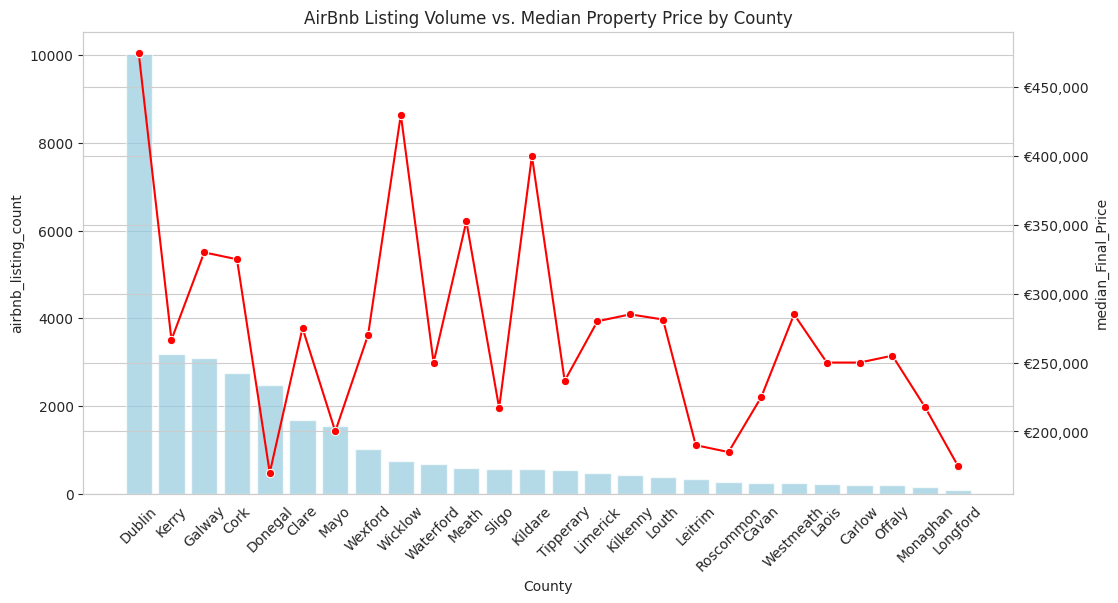

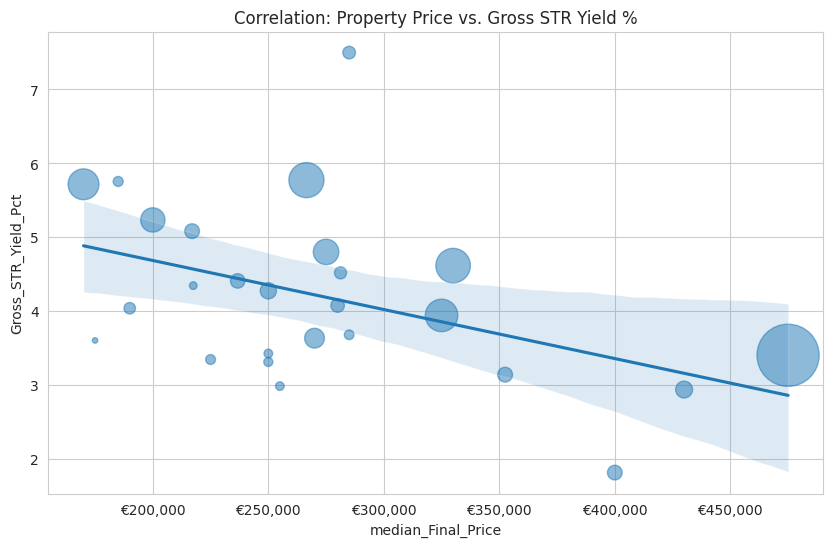

In [ ]:
# Setup for Euro formatting on axes
def euro_formatter(x, pos):
    return f'€{x:,.0f}'

# --- Chart 1: Median Price vs. Listing Count ---
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=county_stats.sort_values("airbnb_listing_count", ascending=False),
            x="County", y="airbnb_listing_count", color="skyblue", ax=ax1, alpha=0.7)
ax2 = ax1.twinx()
sns.lineplot(data=county_stats.sort_values("airbnb_listing_count", ascending=False),
             x="County", y="median_Final_Price", color="red", marker="o", ax=ax2)

ax1.set_title("AirBnb Listing Volume vs. Median Property Price by County")
ax1.tick_params(axis='x', rotation=45)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(euro_formatter))
plt.show()

# --- Chart 2: Yield vs. Price Scatter ---
plt.figure(figsize=(10, 6))
sns.regplot(data=county_stats, x="median_Final_Price", y="Gross_STR_Yield_Pct",
            scatter_kws={'s': county_stats['airbnb_listing_count']/5, 'alpha':0.5})
plt.title("Correlation: Property Price vs. Gross STR Yield %")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(euro_formatter))
plt.show()

Section 4:
4.1 Statistical Analysis

Hypothesis Testing & Statistical Validation

We test the hypothesis that higher STR revenue density correlates with higher residential property values.

In [ ]:
# Pearson Correlation
r_val, p_val = stats.pearsonr(county_stats["median_Final_Price"], county_stats["airbnb_listing_count"])

print(f"--- Statistical Results ---")
print(f"Pearson Correlation (Price vs Listing Density): {r_val:.3f}")
print(f"P-Value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Statistically Significant correlation found.")
else:
    print("Result: No statistically significant linear correlation.")

# Outlier Detection using IQR Fences
def get_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    high = q3 + 1.5 * iqr
    return df[df[col] > high]

price_outliers = get_outliers(county_stats, "median_Final_Price")
print("\nCounties with Exceptionally High Property Values (Outliers):")
print(price_outliers[["County", "median_Final_Price", "Gross_STR_Yield_Pct"]])

--- Statistical Results ---
Pearson Correlation (Price vs Listing Density): 0.536
P-Value: 0.0048
Result: Statistically Significant correlation found.

Counties with Exceptionally High Property Values (Outliers):
     County  median_Final_Price  Gross_STR_Yield_Pct
5    Dublin            475000.0             3.401968
8   Kildare            400000.0             1.814823
25  Wicklow            430000.0             2.938329


Section 5:

Summary for Report

5.1 Preliminary Findings
Based on the analysis above, the following points can be integrated into the Preliminary Analysis section of the interim report:

Market Scale: A significant correlation exists between total inventory and price, suggesting that STR hubs are co-located in high-value residential areas.

Yield Compression: Observations indicate that as property prices increase, gross yields tend to compress, suggesting that STR income does not scale linearly with property acquisition costs.

**Next Steps & Future Analysis**


Regression Modeling: Move from correlation to causation by building a Multiple Linear Regression model to predict Final_Price using airbnb_listing_count and estimated_revenue as features.

Neighborhood Granularity: The current analysis is at the "County" level. Future work will drill down into specific Eircode sectors (e.g., Dublin 1 vs. Dublin 15) to see if localized STR density has a higher impact on prices.

Seasonality Check: Integrate the availability_365 data to adjust "estimated revenue" based on high/low season fluctuations.